<a href="https://colab.research.google.com/github/sondebisola/GroupA--MAITM6341SP25Midterm/blob/main/DEMO_ANN_on_MNIST_Handwriting_Softmax_LONG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import time  # Import the time module
import random

In [2]:
RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

EPOCHS = 100
PATIENCE = 5
RANDOM_SEED = 23
BATCH_SIZE = 32

## Prepare the data

In [3]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

## Data Quality Checks

In [4]:
# 1. Check for missing values (NaN/null)
print("="*60)
print("MISSING VALUE CHECKS")
print("="*60)
print(f"Training data - NaN count in X: {np.isnan(x_train).sum()}")
print(f"Training data - NaN count in y: {np.isnan(y_train).sum()}")
print(f"Test data - NaN count in X: {np.isnan(x_test).sum()}")
print(f"Test data - NaN count in y: {np.isnan(y_test).sum()}")

# 2. Shape validation - verify all images are 28x28
print("\n" + "="*60)
print("SHAPE VALIDATION")
print("="*60)
expected_shape = (28, 28)
print(f"Expected image shape: {expected_shape}")
print(f"All training images have correct shape: {all(img.shape == expected_shape for img in x_train)}")
print(f"All test images have correct shape: {all(img.shape == expected_shape for img in x_test)}")

# 3. Pixel range validation - check values are 0-255 before normalization
print("\n" + "="*60)
print("PIXEL RANGE VALIDATION (Before Normalization)")
print("="*60)
print(f"Training data - Min pixel value: {x_train.min()}")
print(f"Training data - Max pixel value: {x_train.max()}")
print(f"Test data - Min pixel value: {x_test.min()}")
print(f"Test data - Max pixel value: {x_test.max()}")
print(f"All pixel values in valid range [0, 255]: {x_train.min() >= 0 and x_train.max() <= 255 and x_test.min() >= 0 and x_test.max() <= 255}")

# 4. Label validation - verify labels are within expected range (0-9)
print("\n" + "="*60)
print("LABEL VALIDATION")
print("="*60)
unique_train_labels = np.unique(y_train)
unique_test_labels = np.unique(y_test)
print(f"Unique training labels: {unique_train_labels}")
print(f"Unique test labels: {unique_test_labels}")
print(f"All training labels in range [0, 9]: {y_train.min() >= 0 and y_train.max() <= 9}")
print(f"All test labels in range [0, 9]: {y_test.min() >= 0 and y_test.max() <= 9}")

# 5. Detect corrupted images - all-black or all-white images
print("\n" + "="*60)
print("CORRUPTED IMAGE DETECTION")
print("="*60)
all_black_train = np.sum([np.all(img == 0) for img in x_train])
all_white_train = np.sum([np.all(img == 255) for img in x_train])
all_black_test = np.sum([np.all(img == 0) for img in x_test])
all_white_test = np.sum([np.all(img == 255) for img in x_test])

print(f"Training data - All-black images: {all_black_train}")
print(f"Training data - All-white images: {all_white_train}")
print(f"Test data - All-black images: {all_black_test}")
print(f"Test data - All-white images: {all_white_test}")

# 6. Check for duplicate images
print("\n" + "="*60)
print("DUPLICATE DETECTION")
print("="*60)
# Flatten images for comparison
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Check for duplicates within training set
unique_train = np.unique(x_train_flat, axis=0)
duplicates_train = x_train.shape[0] - unique_train.shape[0]
print(f"Duplicate images in training set: {duplicates_train}")

# Check for duplicates within test set
unique_test = np.unique(x_test_flat, axis=0)
duplicates_test = x_test.shape[0] - unique_test.shape[0]
print(f"Duplicate images in test set: {duplicates_test}")

print("\n" + "="*60)
print("DATA QUALITY CHECK COMPLETE ✓")
print("="*60)

MISSING VALUE CHECKS
Training data - NaN count in X: 0
Training data - NaN count in y: 0
Test data - NaN count in X: 0
Test data - NaN count in y: 0

SHAPE VALIDATION
Expected image shape: (28, 28)
All training images have correct shape: True
All test images have correct shape: True

PIXEL RANGE VALIDATION (Before Normalization)
Training data - Min pixel value: 0
Training data - Max pixel value: 255
Test data - Min pixel value: 0
Test data - Max pixel value: 255
All pixel values in valid range [0, 255]: True

LABEL VALIDATION
Unique training labels: [0 1 2 3 4 5 6 7 8 9]
Unique test labels: [0 1 2 3 4 5 6 7 8 9]
All training labels in range [0, 9]: True
All test labels in range [0, 9]: True

CORRUPTED IMAGE DETECTION


Training data - All-black images: 0
Training data - All-white images: 0
Test data - All-black images: 0
Test data - All-white images: 0

DUPLICATE DETECTION


Duplicate images in training set: 0


Duplicate images in test set: 0

DATA QUALITY CHECK COMPLETE ✓


In [5]:
print("TRAINNG DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_train.shape)
# Can see that we have one label for each of the 60,000 images
print(y_train.shape)

print("\nTESTING DATA")
# Can see that in x data we have 10,000 28x28 pixel images
print(x_test.shape)
# Can see that we have one label for each of the 10,000 images
print(y_test.shape)

print('\n Testing to Training ratio =', x_test.shape[0]/x_train.shape[0])

TRAINNG DATA
(60000, 28, 28)
(60000,)

TESTING DATA
(10000, 28, 28)
(10000,)

 Testing to Training ratio = 0.16666666666666666


In [6]:
# Can see each element in x data is 28x28 array where each value is the grayscale value of the pixel from 0-255 where black(255)/white(0)
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
# Normalize the x data to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
# Can see that we successfully normalized x data
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [9]:
# Can see that the target value is the correct digit 0-9
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [10]:
# Count the number of occurrences of each class in y_train and y_test
train_class_counts = np.bincount(y_train)
test_class_counts = np.bincount(y_test)

# Print the counts for the training data
print("Class counts in the training data:")
for i in range(len(train_class_counts)):
    print(f"Digit {i}: {train_class_counts[i]} samples")

# Print the counts for the test data
print("\nClass counts in the test data:")
for i in range(len(test_class_counts)):
    print(f"Digit {i}: {test_class_counts[i]} samples")

Class counts in the training data:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Class counts in the test data:
Digit 0: 980 samples
Digit 1: 1135 samples
Digit 2: 1032 samples
Digit 3: 1010 samples
Digit 4: 982 samples
Digit 5: 892 samples
Digit 6: 958 samples
Digit 7: 1028 samples
Digit 8: 974 samples
Digit 9: 1009 samples


In [11]:
# Split the training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=x_test.shape[0], random_state=RANDOM_SEED)

In [12]:
print("TRAINNG DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_train.shape)

print("\nVALIDATION DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_val.shape)

print("\nTEST DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_test.shape)

# Run this cell to see train/val/test split by proportion
total_data_size = x_train.shape[0] + x_val.shape[0] + x_test.shape[0]
print("\nTraining data proportion:", x_train.shape[0]/total_data_size)
print("Validation data proportion:", x_val.shape[0]/total_data_size)
print("Testing data proportion:", x_test.shape[0]/total_data_size)

TRAINNG DATA
(50000, 28, 28)

VALIDATION DATA
(10000, 28, 28)

TEST DATA
(10000, 28, 28)

Training data proportion: 0.7142857142857143
Validation data proportion: 0.14285714285714285
Testing data proportion: 0.14285714285714285


## Build and Train the Model

In [13]:
# Build the neural network
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),  # Input layer
    keras.layers.Flatten(),  # Flatten the 28x28 input images
    keras.layers.Dense(units=32, activation='relu'),   # Fully connected layer
    keras.layers.Dense(units=16, activation='relu'),    # Additional hidden layer
    keras.layers.Dense(units=10, activation='softmax')  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss= 'sparse_categorical_crossentropy',  # Use SparseCategoricalCrossentropy for integer labels
              metrics=['accuracy'],# FYI, if loss='sparse_categorical_crossentropy', Keras will use sparse_categorical_accuracy even if you put metrics=['accuracy']
              #metrics=['sparse_categorical_accuracy'],  # Use sparse categorical accuracy as a metric for integer labels
)

In [14]:
# total number of parameters in model
total_params = model.count_params()
print(f"Total number of parameters: {total_params}")

# total number of trainable parameters in model
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
print(f"Number of trainable parameters: {trainable_params}")

Total number of parameters: 25818
Number of trainable parameters: 25818


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# from tensorflow.keras.utils import plot_model

# # Plot the model
# plot_model(model, to_file='ANN_model.png', show_shapes=True, show_layer_names=True)

In [17]:
# --- Implement Early Stopping ---
# Define the EarlyStopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor
    patience=PATIENCE,          # Number of epochs to wait for improvement
    verbose=1,           # Print a message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value
)

# --- Train the Neural Network ---
# Start the timer
start_time = time.time()
# Train the model
history = model.fit(x_train,
                    y_train,
                    validation_data=(x_val, y_val), # Here I explicitly used the validation data made earlier
                    epochs=EPOCHS,
                    callbacks=[early_stopping], # Add the early stopping callback here
                    batch_size=BATCH_SIZE,
                    )

# Stop the timer
end_time = time.time()
# Calculate training time
training_time = end_time - start_time
# Print the training time
print("Training Time: {:.2f} seconds".format(training_time))

Epoch 1/100


   1/1563 ━━━━━━━━━━━━━━━━━━━━ 15:51 609ms/step - accuracy: 0.0938 - loss: 2.2898

 117/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.3860 - loss: 1.8463   

 241/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.5251 - loss: 1.4896

 363/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.5999 - loss: 1.2783

...

1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.9863 - loss: 0.0492

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 457us/step - accuracy: 0.9861 - loss: 0.0510 - val_accuracy: 0.9597 - val_loss: 0.1637


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 7.


Training Time: 9.93 seconds


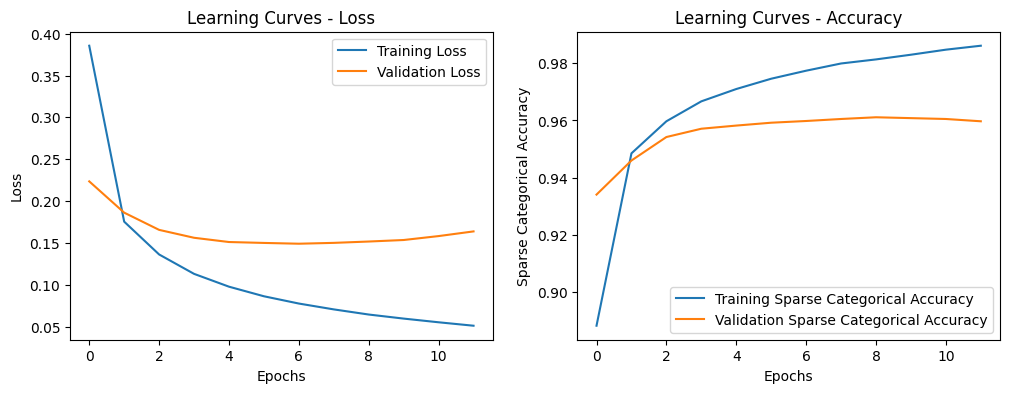

In [18]:
# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Sparse Categorical Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Sparse Categorical Accuracy')
plt.title('Learning Curves - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Sparse Categorical Accuracy')
plt.legend()

plt.show()

##Evaluation

In [19]:
# Have model make predictions on test data
y_pred = model.predict(x_test)

# Convert predictions to class labels
y_pred = np.argmax(y_pred, axis=1)

print(y_pred)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step

233/313 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step


[7 2 1 ... 4 5 6]



Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.93      0.97      0.95      1010
           4       0.95      0.97      0.96       982
           5       0.98      0.93      0.95       892
           6       0.97      0.97      0.97       958
           7       0.98      0.92      0.95      1028
           8       0.96      0.94      0.95       974
           9       0.93      0.95      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000
 




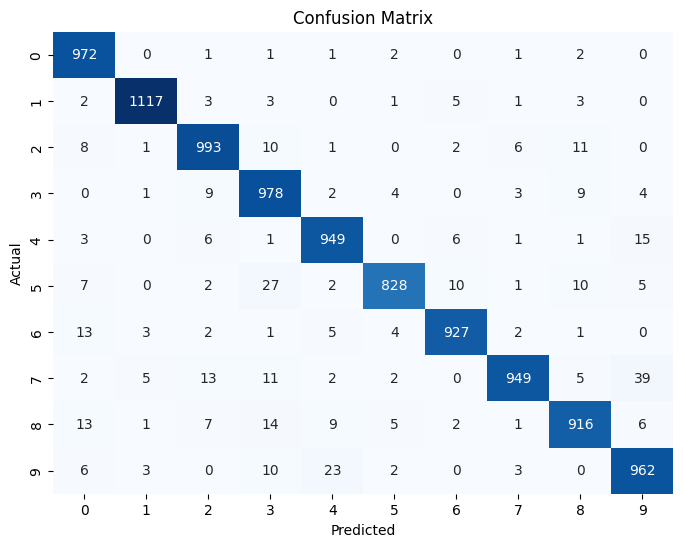

In [20]:
# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred), '\n\n')

# Make confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

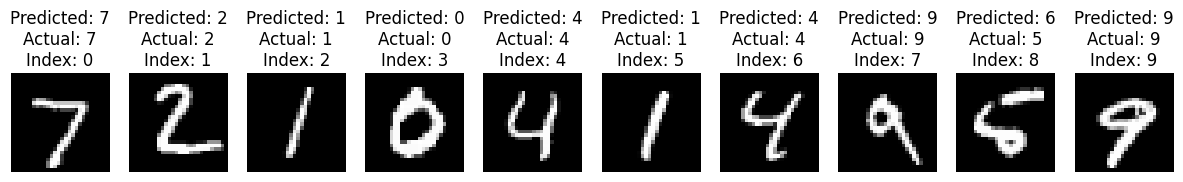

In [21]:
# Display some test images and their predicted labels
num_samples = 10
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}\nActual: {y_test[i]}\nIndex: {i}")
    plt.axis('off')
plt.show()


PREDICTION ERRORS



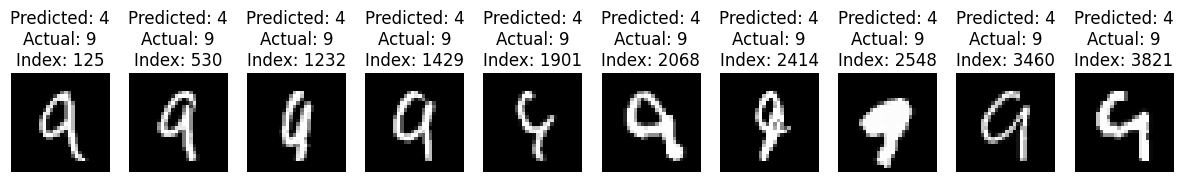

In [22]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==4) & (y_test==9) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()

PREDICTION ERRORS



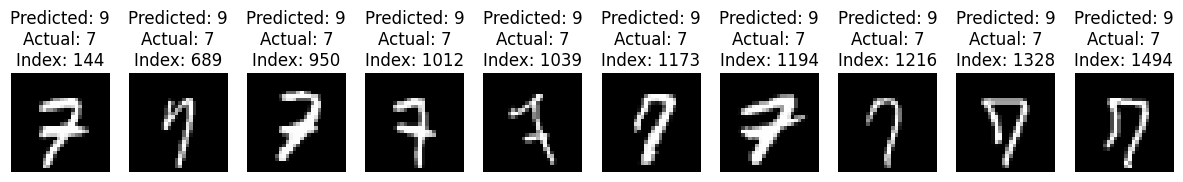

In [23]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==9) & (y_test==7) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()

PREDICTION ERRORS



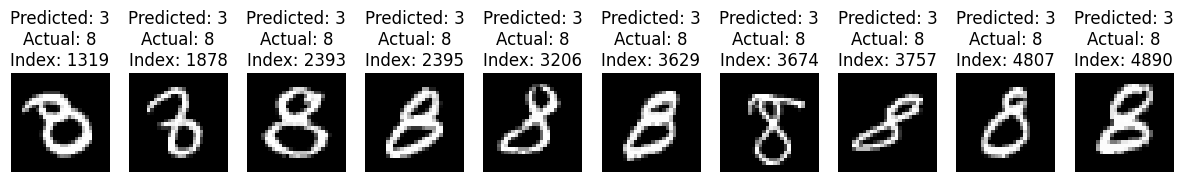

In [24]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==3) & (y_test==8) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()